### H2O

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
import h2o
from h2o.automl import H2OAutoML

In [ ]:
df = pd.read_csv("../data/DataCo_cleaned.csv", low_memory=False)
df.shape

(24840, 52)

In [3]:
# train test split
train, test = train_test_split(df, test_size=0.4, random_state=42)
test, validation = train_test_split(test, test_size=0.5, random_state=42)

In [4]:
# define the target variable
target = 'Order Item Quantity'
features = df.columns.drop(target)


In [5]:
X_train = train[features]
y_train = train[target]
X_test = test[features]
y_test = test[target] 
X_validation = validation[features]
y_validation = validation[target]

In [6]:
h2o.init()

Checking whether there is an H2O instance running at http://localhost:54321. connected.


H2O_cluster_uptime:,3 hours 44 mins
H2O_cluster_timezone:,UTC
H2O_data_parsing_timezone:,UTC
H2O_cluster_version:,3.46.0.8
H2O_cluster_version_age:,1 month and 13 days
H2O_cluster_name:,?
H2O_cluster_total_nodes:,1
H2O_cluster_free_memory:,3.102 Gb
H2O_cluster_total_cores:,10
H2O_cluster_allowed_cores:,10
H2O_cluster_status:,"locked, healthy"


In [7]:
# transform df into a compatible data format
hf_dataset = h2o.H2OFrame(df)

Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%


In [8]:
train, test = hf_dataset.split_frame(ratios=[0.6],seed=1)
test, val = test.split_frame(ratios=[0.5],seed=1)

y = "Order Item Quantity"
X = hf_dataset.columns
X.remove(y)

In [9]:
h2o_aml = H2OAutoML(
    max_models = 12,
    seed = 1, 
    exclude_algos = ["StackedEnsemble"], 
    verbosity="info"
    )

In [10]:
h2o_aml.train(x = X, y = y, training_frame = train)

AutoML progress: |
18:44:39.450: Project: AutoML_13_20251122_184439
18:44:39.451: 5-fold cross-validation will be used.
18:44:39.451: Setting stopping tolerance adaptively based on the training frame: 0.008177787728435172
18:44:39.451: Build control seed: 1
18:44:39.452: training frame: Frame key: AutoML_13_20251122_184439_training_py_2_sid_ad94    cols: 52    rows: 14953  chunks: 4    size: 2753069  checksum: 1642825657018407042
18:44:39.452: validation frame: NULL
18:44:39.452: leaderboard frame: NULL
18:44:39.452: blending frame: NULL
18:44:39.452: response column: Order Item Quantity
18:44:39.452: fold column: null
18:44:39.452: weights column: null
18:44:39.452: Loading execution steps: [{XGBoost : [def_2 (1g, 10w), def_1 (2g, 10w), def_3 (3g, 10w), grid_1 (4g, 90w), lr_search (7g, 30w)]}, {GLM : [def_1 (1g, 10w)]}, {DRF : [def_1 (2g, 10w), XRT (3g, 10w)]}, {GBM : [def_5 (1g, 10w), def_2 (2g, 10w), def_3 (2g, 10w), def_4 (2g, 10w), def_1 (3g, 10w), grid_1 (4g, 60w), lr_annealing (

Model Details
=============
H2OXGBoostEstimator : XGBoost
Model Key: XGBoost_1_AutoML_13_20251122_184439


Model Summary: 
    number_of_trees
--  -----------------
    95

ModelMetricsRegression: xgboost
** Reported on train data. **

MSE: 0.0001485220322619423
RMSE: 0.01218696156808342
MAE: 0.004476718425686955
RMSLE: 0.0032640048075222197
Mean Residual Deviance: 0.0001485220322619423

ModelMetricsRegression: xgboost
** Reported on cross-validation data. **

MSE: 0.0010441295088994057
RMSE: 0.0323129928805644
MAE: 0.008122368591697385
RMSLE: 0.008503681190277132
Mean Residual Deviance: 0.0010441295088994057

Cross-Validation Metrics Summary: 
                        mean        sd           cv_1_valid    cv_2_valid    cv_3_valid    cv_4_valid    cv_5_valid
----------------------  ----------  -----------  ------------  ------------  ------------  ------------  ------------
aic                     nan         0            nan           nan           nan           nan           nan
loglikelihood           nan         0            nan           nan           nan           nan           nan
mae                     0.0081224   0.000752169  0.00701515    0.00782842    0.00900757    0.00825024    0.00851064
mean_residual_deviance  0.00104413  0.000231493  0.000811914   0.000962902   0.00139109    0.0011556     0.000899127
mse                     0.00104413  0.000231493  0.000811914   0.000962902   0.00139109    0.0011556     0.000899127
r2                      0.999518    0.000109078  0.999623      0.999555      0.999356      0.99946       0.999593
residual_deviance       0.00104413  0.000231493  0.000811914   0.000962902   0.00139109    0.0011556     0.000899127
rmse                    0.0321603   0.0035071    0.0284941     0.0310307     0.0372973     0.0339942     0.0299854
rmsle                   0.00840859  0.00141854   0.00760097    0.00799154    0.00836516    0.0108339     0.00725143

Scoring History: 
    timestamp            duration    number_of_trees    training_rmse    training_mae    training_deviance
--  -------------------  ----------  -----------------  ---------------  --------------  -------------------
    2025-11-22 18:45:06  27.124 sec  0                  2.24757          1.69849         5.05158
    2025-11-22 18:45:06  27.416 sec  5                  0.393206         0.290564        0.154611
    2025-11-22 18:45:07  27.620 sec  10                 0.0780251        0.0519119       0.00608792
    2025-11-22 18:45:07  27.951 sec  15                 0.0301521        0.0126292       0.000909149
    2025-11-22 18:45:07  28.287 sec  20                 0.0241626        0.00665578      0.000583831
    2025-11-22 18:45:08  28.752 sec  25                 0.0223272        0.0060536       0.000498503
    2025-11-22 18:45:08  29.099 sec  30                 0.0210514        0.00602794      0.000443161
    2025-11-22 18:45:08  29.475 sec  35                 0.0193061        0.00568789      0.000372724
    2025-11-22 18:45:09  29.840 sec  40                 0.0181507        0.00547656      0.000329447
    2025-11-22 18:45:09  30.211 sec  45                 0.0174035        0.00535301      0.000302881
    2025-11-22 18:45:10  30.569 sec  50                 0.016725         0.00525421      0.000279725
    2025-11-22 18:45:10  30.918 sec  55                 0.0162248        0.00519134      0.000263244
    2025-11-22 18:45:10  31.278 sec  60                 0.0157461        0.00516921      0.000247939
    2025-11-22 18:45:11  31.654 sec  65                 0.0150125        0.00500405      0.000225375
    2025-11-22 18:45:11  32.015 sec  70                 0.0143657        0.00490089      0.000206374
    2025-11-22 18:45:11  32.386 sec  75                 0.0138145        0.00479077      0.000190839
    2025-11-22 18:45:12  32.768 sec  80                 0.0133111        0.00473171      0.000177185
    2025-11-22 18:45:12  33.156 sec  85                 0.01289          0.00463726      0.000166153
    2025-11-22 18:45:12  33.527 sec  9

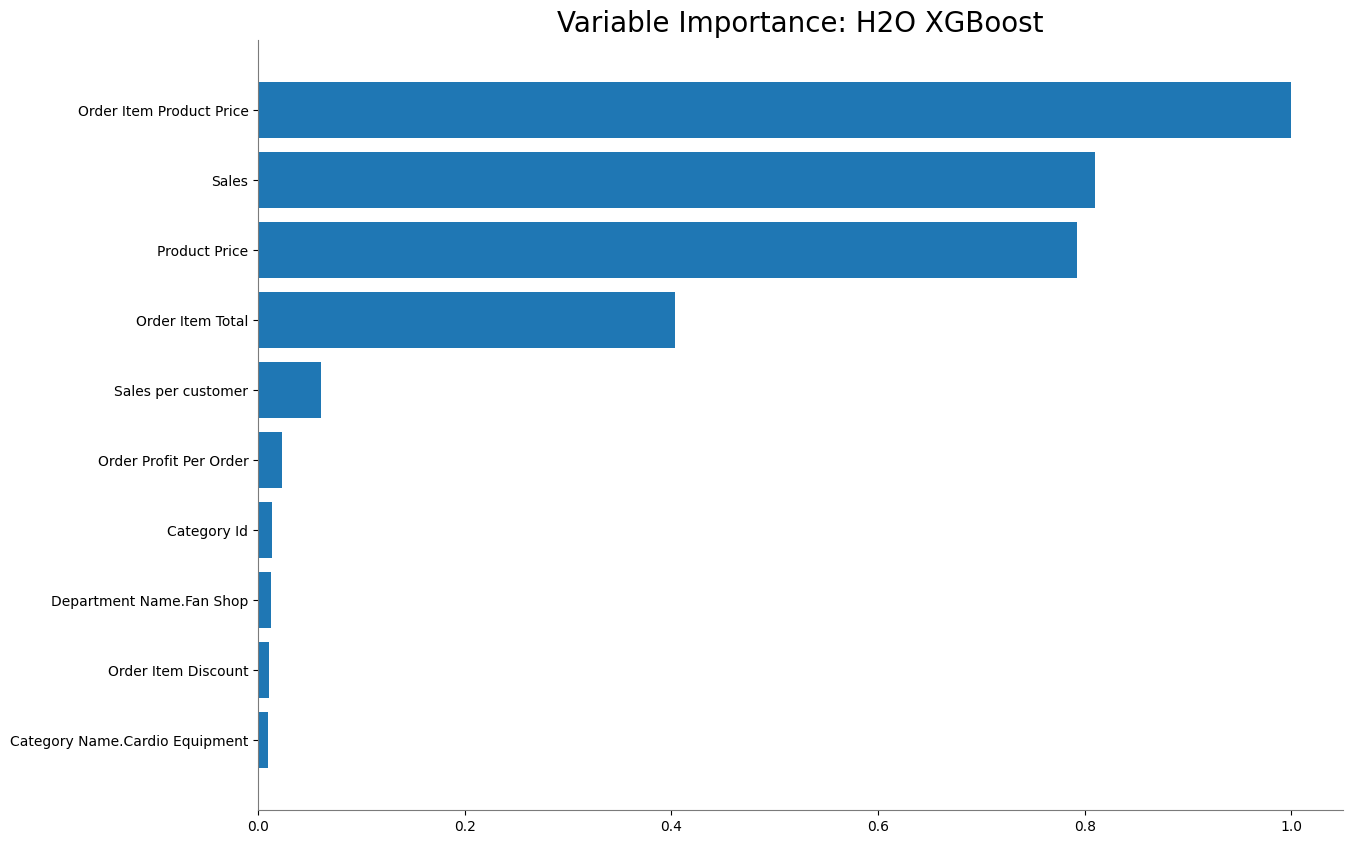

<Figure size 640x480 with 0 Axes>

In [11]:
# plot importances
h2o_aml.leader.varimp_plot()

In [12]:
se = h2o_aml.leader

h2o_lb = h2o_aml.leaderboard
h2o_lb.head(rows = h2o_lb.nrows)

model_id,rmse,mse,mae,rmsle,mean_residual_deviance
XGBoost_1_AutoML_13_20251122_184439,0.032313,0.00104413,0.00812237,0.00850368,0.00104413
XGBoost_2_AutoML_13_20251122_184439,0.0325054,0.0010566,0.00833968,0.00860244,0.0010566
XGBoost_3_AutoML_13_20251122_184439,0.0353179,0.00124735,0.0109536,0.00912897,0.00124735
GBM_4_AutoML_13_20251122_184439,0.0771571,0.00595322,0.0306731,0.0181812,0.00595322
GBM_3_AutoML_13_20251122_184439,0.0780496,0.00609175,0.0227081,0.0173893,0.00609175
GBM_5_AutoML_13_20251122_184439,0.0843331,0.00711207,0.0341278,0.0197022,0.00711207
GBM_2_AutoML_13_20251122_184439,0.0932426,0.00869418,0.0366516,0.0210391,0.00869418
DRF_1_AutoML_13_20251122_184439,0.0954958,0.00911944,0.0347218,0.0220523,0.00911944
XRT_1_AutoML_13_20251122_184439,0.0982215,0.00964747,0.049765,0.0220187,0.00964747
GBM_1_AutoML_13_20251122_184439,0.098498,0.00970185,0.0441294,0.0258745,0.00970185


In [13]:
se

Model Details
=============
H2OXGBoostEstimator : XGBoost
Model Key: XGBoost_1_AutoML_13_20251122_184439


Model Summary: 
    number_of_trees
--  -----------------
    95

ModelMetricsRegression: xgboost
** Reported on train data. **

MSE: 0.0001485220322619423
RMSE: 0.01218696156808342
MAE: 0.004476718425686955
RMSLE: 0.0032640048075222197
Mean Residual Deviance: 0.0001485220322619423

ModelMetricsRegression: xgboost
** Reported on cross-validation data. **

MSE: 0.0010441295088994057
RMSE: 0.0323129928805644
MAE: 0.008122368591697385
RMSLE: 0.008503681190277132
Mean Residual Deviance: 0.0010441295088994057

Cross-Validation Metrics Summary: 
                        mean        sd           cv_1_valid    cv_2_valid    cv_3_valid    cv_4_valid    cv_5_valid
----------------------  ----------  -----------  ------------  ------------  ------------  ------------  ------------
aic                     nan         0            nan           nan           nan           nan           nan
loglikelihood           nan         0            nan           nan           nan           nan           nan
mae                     0.0081224   0.000752169  0.00701515    0.00782842    0.00900757    0.00825024    0.00851064
mean_residual_deviance  0.00104413  0.000231493  0.000811914   0.000962902   0.00139109    0.0011556     0.000899127
mse                     0.00104413  0.000231493  0.000811914   0.000962902   0.00139109    0.0011556     0.000899127
r2                      0.999518    0.000109078  0.999623      0.999555      0.999356      0.99946       0.999593
residual_deviance       0.00104413  0.000231493  0.000811914   0.000962902   0.00139109    0.0011556     0.000899127
rmse                    0.0321603   0.0035071    0.0284941     0.0310307     0.0372973     0.0339942     0.0299854
rmsle                   0.00840859  0.00141854   0.00760097    0.00799154    0.00836516    0.0108339     0.00725143

Scoring History: 
    timestamp            duration    number_of_trees    training_rmse    training_mae    training_deviance
--  -------------------  ----------  -----------------  ---------------  --------------  -------------------
    2025-11-22 18:45:06  27.124 sec  0                  2.24757          1.69849         5.05158
    2025-11-22 18:45:06  27.416 sec  5                  0.393206         0.290564        0.154611
    2025-11-22 18:45:07  27.620 sec  10                 0.0780251        0.0519119       0.00608792
    2025-11-22 18:45:07  27.951 sec  15                 0.0301521        0.0126292       0.000909149
    2025-11-22 18:45:07  28.287 sec  20                 0.0241626        0.00665578      0.000583831
    2025-11-22 18:45:08  28.752 sec  25                 0.0223272        0.0060536       0.000498503
    2025-11-22 18:45:08  29.099 sec  30                 0.0210514        0.00602794      0.000443161
    2025-11-22 18:45:08  29.475 sec  35                 0.0193061        0.00568789      0.000372724
    2025-11-22 18:45:09  29.840 sec  40                 0.0181507        0.00547656      0.000329447
    2025-11-22 18:45:09  30.211 sec  45                 0.0174035        0.00535301      0.000302881
    2025-11-22 18:45:10  30.569 sec  50                 0.016725         0.00525421      0.000279725
    2025-11-22 18:45:10  30.918 sec  55                 0.0162248        0.00519134      0.000263244
    2025-11-22 18:45:10  31.278 sec  60                 0.0157461        0.00516921      0.000247939
    2025-11-22 18:45:11  31.654 sec  65                 0.0150125        0.00500405      0.000225375
    2025-11-22 18:45:11  32.015 sec  70                 0.0143657        0.00490089      0.000206374
    2025-11-22 18:45:11  32.386 sec  75                 0.0138145        0.00479077      0.000190839
    2025-11-22 18:45:12  32.768 sec  80                 0.0133111        0.00473171      0.000177185
    2025-11-22 18:45:12  33.156 sec  85                 0.01289          0.00463726      0.000166153
    2025-11-22 18:45:12  33.527 sec  9

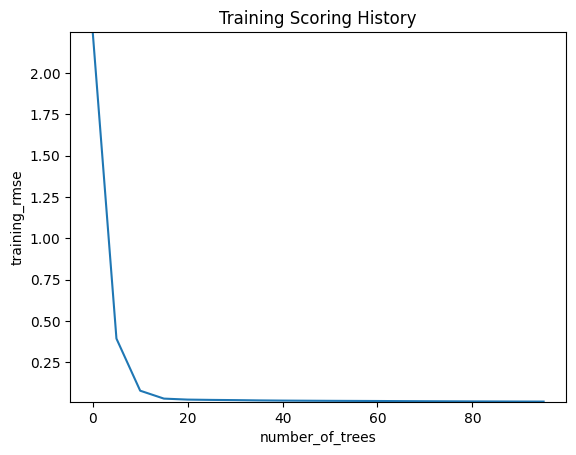

In [14]:
# plot scoring history trees and training_logloss
se.plot()

### MLflow

In [1]:
import mlflow
import mlflow.sklearn

#mlflow.set_tracking_uri("file:///mlruns")  # Set this to your MLflow server or leave as default for local tracking


In [2]:
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
DATA_PATH = Path() / "../data"
#DATA_PATH = Path('/content/gdrive/My Drive/Colab Notebooks/VC_data_Cleaning_With_LLM/data')
DATA_PATH.mkdir(parents=True,exist_ok=True)

def load_csv(filename, data_path=DATA_PATH,encoding='ISO-8859-1'):
    csv_path = data_path / filename
    return pd.read_csv(csv_path,encoding=encoding)

def save_csv(data, filename, data_path=DATA_PATH,encoding='ISO-8859-1'):
    csv_path = data_path / filename
    data.to_csv(csv_path, index=False,encoding='ISO-8859-1')

def load_excel(filename, data_path=DATA_PATH):
    csv_path = data_path / filename
    return pd.read_excel(csv_path)

PLOT_PATH = Path() / "../plot"
#PLOT_PATH = Path('/content/gdrive/My Drive/Colab Notebooks/VC_data_Cleaning_With_LLM/plot')
PLOT_PATH.mkdir(parents=True,exist_ok=True)

def save_fig(fig_id, tight_layout=True, fig_extension="png", resolution=300, transparent=True):
    path = PLOT_PATH / f"{fig_id}.{fig_extension}"
    print("Saving figure", fig_id)
    if tight_layout:
        plt.tight_layout()
    plt.savefig(path, format=fig_extension, dpi=resolution, transparent=transparent)

RESULT_PATH = Path() / "../result"
#PLOT_PATH = Path('/content/gdrive/My Drive/Colab Notebooks/VC_data_Cleaning_With_LLM/plot')
RESULT_PATH.mkdir(parents=True,exist_ok=True)
def save_result(data, filename, data_path=RESULT_PATH):
    csv_path = data_path / filename
    data.to_csv(csv_path, index=False, encoding='utf-8-sig')

def save_excel(data, filename, data_path=RESULT_PATH):
    csv_path = data_path / filename
    data.to_excel(csv_path, index=False)

import h2o

# Define the default path where models will be saved
MODEL_PATH = Path() / "../models"
MODEL_PATH.mkdir(parents=True, exist_ok=True)

def save_h2o_model(model, filename, model_path=RESULT_PATH):
    full_path = model_path / filename
    full_path.parent.mkdir(parents=True, exist_ok=True)
    saved_model_path = h2o.save_model(model=model, path=str(full_path.parent), force=True)
    print(f"Model saved to: {saved_model_path}")
    return saved_model_path


Checking whether there is an H2O instance running at http://localhost:54321. connected.


H2O_cluster_uptime:,3 hours 29 mins
H2O_cluster_timezone:,America/Toronto
H2O_data_parsing_timezone:,UTC
H2O_cluster_version:,3.46.0.1
H2O_cluster_version_age:,1 month and 10 days
H2O_cluster_name:,H2O_from_python_TYS_gefzhk
H2O_cluster_total_nodes:,1
H2O_cluster_free_memory:,3.662 Gb
H2O_cluster_total_cores:,8
H2O_cluster_allowed_cores:,8
H2O_cluster_status:,"locked, healthy"


Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
AutoML progress: |█
18:45:08.78: Project: AutoML_8_20240423_184508
18:45:08.78: 5-fold cross-validation will be used.
18:45:08.79: Setting stopping tolerance adaptively based on the training frame: 0.028676966733820218
18:45:08.79: Build control seed: 1
18:45:08.79: training frame: Frame key: AutoML_8_20240423_184508_training_py_2_sid_b16b    cols: 22    rows: 1216  chunks: 1    size: 208582  checksum: -140458100710306879
18:45:08.79: validation frame: NULL
18:45:08.79: leaderboard frame: NULL
18:45:08.79: blending frame: NULL
18:45:08.79: response column: Order Item Quantity
18:45:08.80: fold column: null
18:45:08.80: weights column: null
18:45:08.81: AutoML: XGBoost is not available; skipping it.
18:45:08.81: Loading execution steps: [{XGBoost : [def_2 (1g, 10w), def_1 (2g, 10w), def_3 (3g, 10w), grid_1 (4g, 90w), lr_search (7g, 30w)]}, {GLM : [def_1 (1g, 10w)]}, {DRF : [def_1 (2g, 10w), XR

c:\Users\TYS\AppData\Local\Programs\Python\Python311\Lib\site-packages\_distutils_hack\__init__.py:33: UserWarning: Setuptools is replacing distutils.
  warnings.warn("Setuptools is replacing distutils.")


Model saved to: C:\Users\TYS\Documents\study\Master\INSY695 Enterprise Data Science II\Final Project\DataCo_Supply_Chain\result\DeepLearning_1_AutoML_8_20240423_184508


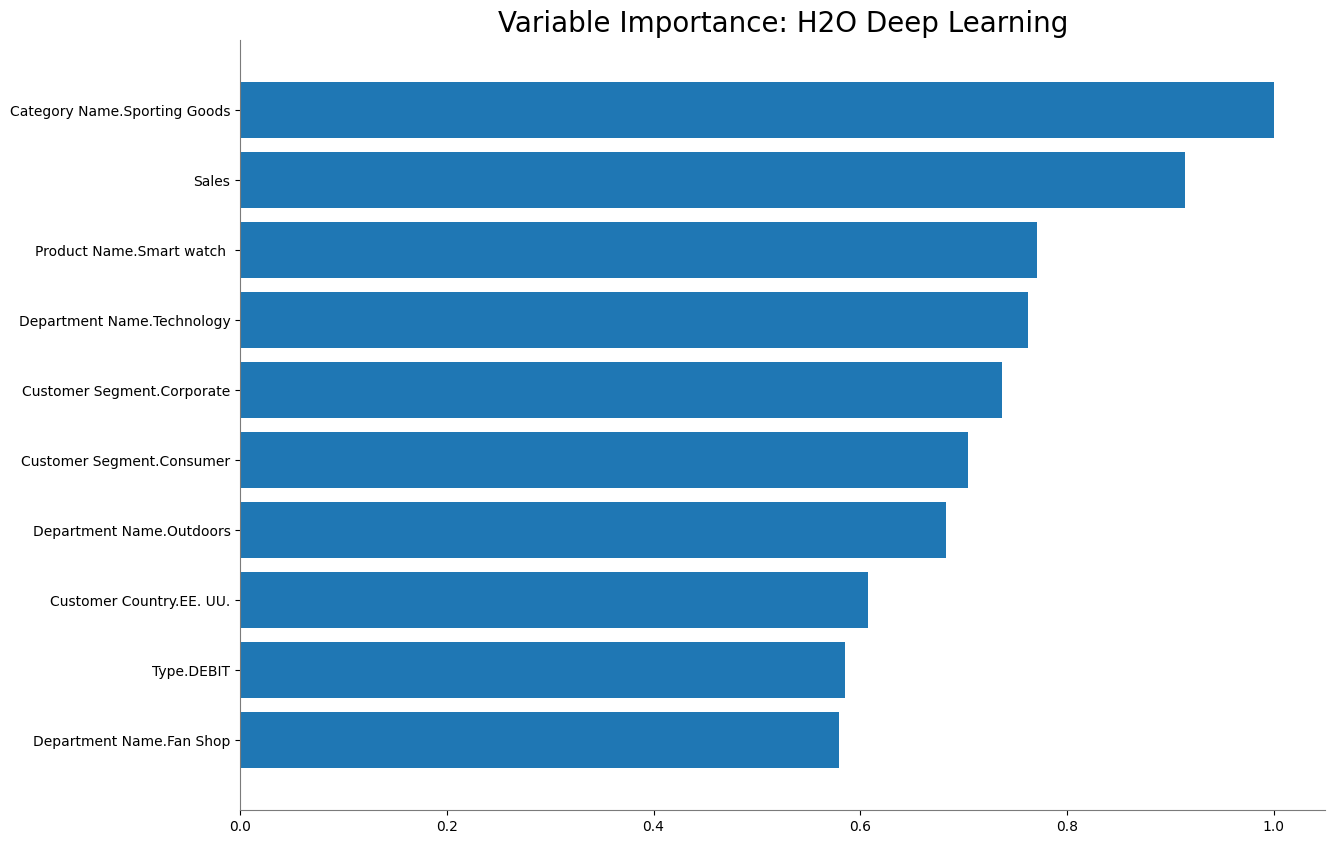

c:\Users\TYS\AppData\Local\Programs\Python\Python311\Lib\site-packages\h2o\frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install datatable (for Python 3.9 or lower), or polars and pyarrow (for Python 3.10 or above) and activate it using:

with h2o.utils.threading.local_context(polars_enabled=True, datatable_enabled=True):
    pandas_df = h2o_df.as_data_frame()

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"


<Figure size 640x480 with 0 Axes>

In [3]:
import numpy as np
from sklearn.model_selection import train_test_split
import h2o
from h2o.automl import H2OAutoML
import mlflow
import mlflow.h2o

# Initialize H2O
h2o.init()

# Load data
df = load_csv("DataCo_cleaned.csv")

# H2O Frame
hf_dataset = h2o.H2OFrame(df)
train, test = hf_dataset.split_frame(ratios=[0.6], seed=1)
#test, val = test.split_frame(ratios=[0.5], seed=1)

# Define the target and features
y = "Order Item Quantity"
X = hf_dataset.columns
X.remove(y)

# Start MLflow experiment
with mlflow.start_run():
    # Configure and run H2O AutoML
    h2o_aml = H2OAutoML(max_models=12, seed=1, exclude_algos=["StackedEnsemble"], verbosity="info")
    h2o_aml.train(x=X, y=y, training_frame=train)

    # Log model
    mlflow.h2o.log_model(h2o_aml.leader, "model")

    # Now, save the model using the new function
    model_filename = "best_model_demand_forcasting"
    save_h2o_model(h2o_aml.leader, model_filename)

    # Logging parameters and metrics
    mlflow.log_params({
        "max_models": 12,
        "exclude_algos": "StackedEnsemble",
        "seed": 1
    })

    # Access performance metrics from the leaderboard
    perf = h2o_aml.leader.model_performance(test)
    mlflow.log_metrics({
        "rmse": perf.rmse(),
        "mae": perf.mae(),
        "r2": perf.r2()
    })

    # Variable importance plot
    h2o_aml.leader.varimp_plot()
    #save_fig(varimp_plot,"varimp_plot")
    # Log the leaderboard
    lb = h2o_aml.leaderboard.as_data_frame()
    lb.to_csv("leaderboard.csv", index=False)
    save_result(lb, "leaderboard.csv")
    mlflow.log_artifact("leaderboard.csv")

    # End run
    mlflow.end_run()
